<a href="https://colab.research.google.com/github/nomin-hub/AIFFEL_quest_cr/blob/main/NLP/NLP01/Attentional_Seq2seq_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 0. 환경 설치

In [2]:
!sudo apt-get update -qq
!sudo apt-get install -y -qq fonts-nanum
!pip install -q tensorflow sentencepiece python-mecab-ko python-mecab-ko-dic tqdm


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 기본 라이브러리 & 폰트 설정

In [3]:
import numpy as np
import tensorflow as tf
import re, time, os
from tqdm import tqdm

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
if os.path.exists(fontpath):
    fontprop = fm.FontProperties(fname=fontpath, size=12)
    plt.rcParams["font.family"] = fontprop.get_name()
    plt.rcParams["axes.unicode_minus"] = False
    print(f"설정된 폰트: {fontprop.get_name()}")
else:
    fontprop = None
    print("나눔 폰트를 찾을 수 없습니다.")

print("TensorFlow 버전:", tf.__version__)
print("ㅇ~")


설정된 폰트: NanumBarunGothic
TensorFlow 버전: 2.20.0
ㅇ~


## MeCab 초기화

> 과제 요구사항은 KoNLPy의 Mecab 클래스 사용이지만,
> 현재 실습 환경에서는 apt-get 권한 제한으로 mecab-ko-dic 설치가 불가능했습니다.
> 따라서 **pip로 설치 가능한 python-mecab-ko** 를 사용해 동일하게 Mecab 형태소 분석을 수행합니다.


In [4]:
from mecab import MeCab

mecab = MeCab()
print("형태소 분석 테스트:", mecab.morphs("나는 오늘 자연어처리를 공부합니다."))
print("ㅇ~")


형태소 분석 테스트: ['나', '는', '오늘', '자연어', '처리', '를', '공부', '합니다', '.']
ㅇ~


## Step 1. 데이터 다운로드

출처: [jungyeul/korean-parallel-corpora](https://github.com/jungyeul/korean-parallel-corpora/tree/master/korean-english-news-v1)


In [5]:
import os
# 압축 해제된 파일 구조 확인
for root, dirs, files in os.walk("."):
    for f in files:
        if "korean" in f or "park" in f:
            print(os.path.join(root, f))

In [6]:
import urllib.request
import tarfile

url      = "https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz"
tar_path = "korean-english-park.train.tar.gz"

if not os.path.exists("korean-english-park.train.ko"):
    print("데이터 다운로드 중...")
    urllib.request.urlretrieve(url, tar_path)
    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(".")
    print("압축 해제 완료!")
else:
    print("이미 데이터가 존재합니다.")

ko_path = "korean-english-park.train.ko"
en_path = "korean-english-park.train.en"

with open(ko_path, "r", encoding="utf-8") as f:
    kor_lines = f.read().strip().split("\n")
with open(en_path, "r", encoding="utf-8") as f:
    eng_lines = f.read().strip().split("\n")

corpus = list(zip(kor_lines, eng_lines))

print("한국어 문장 수:", len(kor_lines))
print("영어 문장 수:",   len(eng_lines))
print("corpus 개수:",    len(corpus))
print("예시:",           corpus[0])

데이터 다운로드 중...


/tmp/ipykernel_6161/2507888863.py:11: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(".")


압축 해제 완료!
한국어 문장 수: 94123
영어 문장 수: 94123
corpus 개수: 94123
예시: ('개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"', 'Much of personal computing is about "can you top this?"')


## Step 2. 데이터 정제

### 2-1. preprocessing() 함수 정의

In [7]:
import re

def preprocessing(sentence, lang="eng"):
    """
    문장을 정제하는 함수.
    - lang="eng": 영어 알파벳 + 지정 문장부호만 허용
    - lang="kor": 한글 자모/음절 + 지정 문장부호만 허용
    """
    sentence = str(sentence).lower().strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r"\s+", " ", sentence)

    if lang == "eng":
        sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)
    elif lang == "kor":
        # 한글 자음(ㄱ-ㅎ), 모음(ㅏ-ㅣ), 음절(가-힣)과 문장부호만 남김
        sentence = re.sub(r"[^ㄱ-ㅎㅏ-ㅣ가-힣?.!,]+", " ", sentence)

    sentence = re.sub(r"\s+", " ", sentence)
    return sentence.strip()

print(preprocessing("Hello, World! This is a test.", lang="eng"))
print(preprocessing("안녕하세요! 오늘 날씨가 좋네요.", lang="kor"))
print("ㅇ~")


hello , world ! this is a test .
안녕하세요 ! 오늘 날씨가 좋네요 .
ㅇ~


### 2-2. 중복 제거

`set` 자료형의 중복 불허 특성을 활용해 병렬 쌍이 흐트러지지 않게 중복을 제거합니다.

In [8]:
cleaned_corpus = set()

for kor, eng in corpus:
    kor_clean = preprocessing(kor, lang="kor")
    eng_clean = preprocessing(eng, lang="eng")

    if kor_clean == "" or eng_clean == "":
        continue

    cleaned_corpus.add((kor_clean, eng_clean))

cleaned_corpus = list(cleaned_corpus)

print("중복 제거 전:", len(corpus))
print("중복 제거 후:", len(cleaned_corpus))
print("제거된 쌍:  ", len(corpus) - len(cleaned_corpus))
print("예시:", cleaned_corpus[0])


중복 제거 전: 94123
중복 제거 후: 78785
제거된 쌍:   15338
예시: ('그날 아침 , 경찰은 그가 해병을 살해하고 다른 해병에게 심각한 부상을 입히기 위해 사용했던 무기 일체를 회수했다 .', 'earlier in the day , the police retrieved all weapons he used to murder the marine and severely injure another .')


### 2-3. 토큰화 및 길이 필터링

- **영어(타겟)**: `<start>` / `<end>` 토큰 추가 후 `split()` 토큰화
- **한국어(소스)**: MeCab 형태소 분석
- **토큰 길이 40 이하인 쌍만 선별**


In [9]:
eng_corpus = []
kor_corpus = []

for kor, eng in cleaned_corpus:
    eng_tokens = ("<start> " + eng + " <end>").split()
    kor_tokens = mecab.morphs(kor)

    if len(eng_tokens) <= 40 and len(kor_tokens) <= 40:
        eng_corpus.append(" ".join(eng_tokens))
        kor_corpus.append(" ".join(kor_tokens))

print("eng_corpus 개수:", len(eng_corpus))
print("kor_corpus 개수:", len(kor_corpus))
print()
print("영어 예시:", eng_corpus[0])
print("한국어 예시:", kor_corpus[0])


eng_corpus 개수: 62956
kor_corpus 개수: 62956

영어 예시: <start> earlier in the day , the police retrieved all weapons he used to murder the marine and severely injure another . <end>
한국어 예시: 그날 아침 , 경찰 은 그 가 해병 을 살해 하 고 다른 해병 에게 심각 한 부상 을 입히 기 위해 사용 했 던 무기 일체 를 회수 했 다 .


In [10]:
print("cleaned_corpus 타입:", type(cleaned_corpus))
print("eng_corpus 타입:", type(eng_corpus))
print("kor_corpus 타입:", type(kor_corpus))
print()
print("cleaned_corpus 개수:", len(cleaned_corpus))
print("eng_corpus 개수:", len(eng_corpus))
print("kor_corpus 개수:", len(kor_corpus))


cleaned_corpus 타입: <class 'list'>
eng_corpus 타입: <class 'list'>
kor_corpus 타입: <class 'list'>

cleaned_corpus 개수: 78785
eng_corpus 개수: 62956
kor_corpus 개수: 62956


## Step 3. 데이터 토큰화

`tokenize()` 함수를 사용해 텍스트 데이터를 텐서로 변환합니다. (vocab_size ≥ 10,000)


In [11]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

def tokenize(corpus, vocab_size=12000):
    """
    텍스트 코퍼스를 패딩된 정수 텐서로 변환합니다.
    filters="" 로 설정하여 <start>, <end> 토큰이 필터링되지 않게 합니다.
    """
    tokenizer = Tokenizer(num_words=vocab_size, filters="")
    tokenizer.fit_on_texts(corpus)
    tensor = tokenizer.texts_to_sequences(corpus)
    tensor = pad_sequences(tensor, padding="post")
    return tensor, tokenizer

print("ㅇ~")


ㅇ~


In [12]:
VOCAB_SIZE = 12000  # 10,000 이상

kor_tensor, kor_tokenizer = tokenize(kor_corpus, VOCAB_SIZE)
eng_tensor, eng_tokenizer = tokenize(eng_corpus, VOCAB_SIZE)

print("kor_tensor shape:", kor_tensor.shape)
print("eng_tensor shape:", eng_tensor.shape)
print()
print("한국어 단어장 크기:", len(kor_tokenizer.word_index))
print("영어 단어장 크기:",   len(eng_tokenizer.word_index))
print()
print("<start> token id:", eng_tokenizer.word_index.get("<start>"))
print("<end>   token id:", eng_tokenizer.word_index.get("<end>"))


kor_tensor shape: (62956, 40)
eng_tensor shape: (62956, 40)

한국어 단어장 크기: 37076
영어 단어장 크기: 38539

<start> token id: 3
<end>   token id: 4


In [13]:
print("한국어 tensor 예시:", kor_tensor[0])
print("영어 tensor 예시:", eng_tensor[0])
print()
print("한국어 원문 예시:", kor_corpus[0])
print("영어 원문 예시:", eng_corpus[0])


한국어 tensor 예시: [ 4845   646    17    70     7    24    13  2678     5   424    11    12
    92  2678    54   656    18   247     5  5550    33    63   174     9
    55   660 10823    10  3046     9     2     1     0     0     0     0
     0     0     0     0]
영어 tensor 예시: [   3  216    9    1  101    5    1   63 9964   76  522   21  257    6
 1127    1 1510   10 3976  168    2    4    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0]

한국어 원문 예시: 그날 아침 , 경찰 은 그 가 해병 을 살해 하 고 다른 해병 에게 심각 한 부상 을 입히 기 위해 사용 했 던 무기 일체 를 회수 했 다 .
영어 원문 예시: <start> earlier in the day , the police retrieved all weapons he used to murder the marine and severely injure another . <end>


## Step 4. 모델 설계 — Attention 기반 Seq2seq

### 하이퍼파라미터

| 파라미터 | 값 | 비고 |
|---|---|---|
| `embedding_dim` | 128 | 임베딩 크기 |
| `hidden_size` | 256 | GRU hidden 크기 |
| `BATCH_SIZE` | 32 | 배치 크기 |
| `VOCAB_SIZE` | 12000 | 어휘 크기 |


In [14]:
BUFFER_SIZE = len(kor_tensor)
BATCH_SIZE  = 32

embedding_dim = 128
hidden_size   = 256

src_vocab_size = VOCAB_SIZE
tgt_vocab_size = VOCAB_SIZE

steps_per_epoch = len(kor_tensor) // BATCH_SIZE

dataset = tf.data.Dataset.from_tensor_slices((kor_tensor, eng_tensor))
dataset = dataset.shuffle(BUFFER_SIZE)
dataset = dataset.batch(BATCH_SIZE, drop_remainder=True)

print("BUFFER_SIZE    :", BUFFER_SIZE)
print("BATCH_SIZE     :", BATCH_SIZE)
print("steps_per_epoch:", steps_per_epoch)
print("embedding_dim  :", embedding_dim)
print("hidden_size    :", hidden_size)


BUFFER_SIZE    : 62956
BATCH_SIZE     : 32
steps_per_epoch: 1967
embedding_dim  : 128
hidden_size    : 256


### 4-1. Encoder

In [15]:
class Encoder(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super(Encoder, self).__init__()
        self.hidden_size = hidden_size
        self.embedding   = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.gru = tf.keras.layers.GRU(
            hidden_size,
            return_sequences=True,
            return_state=True,
            recurrent_initializer="glorot_uniform"
        )

    def call(self, x, hidden):
        x = self.embedding(x)
        output, state = self.gru(x, initial_state=hidden)
        return output, state

    def initialize_hidden_state(self, batch_size):
        return tf.zeros((batch_size, self.hidden_size))

print("ㅇ~")


ㅇ~


### 4-2. BahdanauAttention

In [16]:
class BahdanauAttention(tf.keras.layers.Layer):
    def __init__(self, hidden_size):
        super(BahdanauAttention, self).__init__()
        self.W1 = tf.keras.layers.Dense(hidden_size)
        self.W2 = tf.keras.layers.Dense(hidden_size)
        self.V  = tf.keras.layers.Dense(1)

    def call(self, query, values):
        # query : (batch, hidden)       <- Decoder hidden state
        # values: (batch, seq, hidden)  <- Encoder outputs
        query_with_time_axis = tf.expand_dims(query, 1)          # (batch, 1, hidden)
        score = self.V(
            tf.nn.tanh(self.W1(values) + self.W2(query_with_time_axis))
        )                                                         # (batch, seq, 1)
        attention_weights = tf.nn.softmax(score, axis=1)         # (batch, seq, 1)
        context_vector = tf.reduce_sum(attention_weights * values, axis=1)  # (batch, hidden)
        return context_vector, attention_weights

print("ㅇ~")


ㅇ~


### 4-3. Decoder

In [17]:
class Decoder(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super(Decoder, self).__init__()
        self.hidden_size = hidden_size
        self.embedding   = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.gru = tf.keras.layers.GRU(
            hidden_size,
            return_sequences=True,
            return_state=True,
            recurrent_initializer="glorot_uniform"
        )
        self.fc      = tf.keras.layers.Dense(vocab_size)
        self.attention = BahdanauAttention(hidden_size)

    def call(self, x, hidden, enc_output):
        # Attention: context vector 계산
        context_vector, attention_weights = self.attention(hidden, enc_output)

        x = self.embedding(x)                                    # (batch, 1, emb_dim)
        # context vector와 embedding 결합
        x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)

        output, state = self.gru(x)                              # (batch, 1, hidden)
        output = tf.reshape(output, (-1, output.shape[2]))       # (batch, hidden)
        x = self.fc(output)                                      # (batch, vocab_size)

        return x, state, attention_weights

print("ㅇ~")


ㅇ~


### 4-4. Seq2SeqAttention 래퍼 클래스

예시 코드처럼 Encoder + Decoder를 하나의 클래스로 감쌉니다.
- **학습 모드**: Teacher Forcing 사용
- **추론 모드**: `<end>` 토큰이 나오면 조기 종료


In [18]:
class Seq2SeqAttention(tf.keras.Model):
    def __init__(self, encoder, decoder):
        super(Seq2SeqAttention, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, src, trg=None, max_len=40,
             bos_id=None, eos_id=None, training=True):
        """
        src     : (batch, src_seq)
        trg     : (batch, trg_seq)  학습 시에만 사용 (Teacher Forcing)
        training: True → Teacher Forcing / False → 자유 생성(추론)
        """
        batch_size = tf.shape(src)[0]

        enc_hidden = self.encoder.initialize_hidden_state(batch_size)
        enc_output, enc_hidden = self.encoder(src, enc_hidden)

        dec_hidden = enc_hidden
        outputs    = []
        attentions = []

        if training and trg is not None:
            # Teacher Forcing: 정답 토큰을 다음 입력으로 사용
            dec_input = tf.expand_dims(trg[:, 0], 1)  # <start> 토큰
            for t in range(1, trg.shape[1]):
                pred, dec_hidden, attn = self.decoder(dec_input, dec_hidden, enc_output)
                outputs.append(pred)
                attentions.append(attn)
                dec_input = tf.expand_dims(trg[:, t], 1)  # 정답 토큰 입력
        else:
            # 추론 모드: <start> 토큰부터 자유 생성, <end> 나오면 조기 종료
            dec_input = tf.expand_dims([bos_id] * batch_size, 1)
            for t in range(max_len):
                pred, dec_hidden, attn = self.decoder(dec_input, dec_hidden, enc_output)
                outputs.append(pred)
                attentions.append(attn)
                predicted_id = tf.argmax(pred, axis=1)
                dec_input = tf.expand_dims(predicted_id, 1)
                # 배치 전체가 <end>를 출력하면 조기 종료
                if tf.reduce_all(predicted_id == eos_id):
                    break

        return outputs, attentions

print("ㅇ~")


ㅇ~


### 4-5. 모델 초기화 및 Shape 확인

In [19]:
encoder = Encoder(src_vocab_size, embedding_dim, hidden_size)
decoder = Decoder(tgt_vocab_size, embedding_dim, hidden_size)
model   = Seq2SeqAttention(encoder, decoder)

optimizer   = tf.keras.optimizers.Adam(learning_rate=1e-3)
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction="none"
)

# Shape 확인
example_inp, example_targ = next(iter(dataset))
ex_outputs, ex_attentions = model(example_inp, example_targ, training=True)

print("Encoder output shape :", encoder(example_inp, encoder.initialize_hidden_state(BATCH_SIZE))[0].shape)
print("Decoder output shape :", ex_outputs[0].shape)
print("Attention shape      :", ex_attentions[0].shape)
print()
print(model.summary())
print("ㅇ~")


Encoder output shape : (32, 40, 256)
Decoder output shape : (32, 12000)
Attention shape      : (32, 40, 1)



Model: "seq2_seq_attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Encoder)               │ ?                      │     1,832,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Decoder)               │ ?                      │     5,244,897 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,077,345 (27.00 MB)

 Trainable params: 7,077,345 (27.00 MB)

 Non-trainable params: 0 (0.00 B)

None
ㅇ~


## Step 5. 훈련하기

In [20]:
def loss_function(real, pred):
    """패딩(0)을 무시하는 마스킹 손실 함수"""
    mask  = tf.math.logical_not(tf.math.equal(real, 0))
    loss_ = loss_object(real, pred)
    mask  = tf.cast(mask, dtype=loss_.dtype)
    loss_ *= mask
    return tf.reduce_mean(loss_)

print("ㅇ~")


ㅇ~


In [21]:
@tf.function
def train_step(inp, targ, enc_hidden):
    loss = 0
    with tf.GradientTape() as tape:
        enc_output, enc_hidden = encoder(inp, enc_hidden)
        dec_hidden = enc_hidden

        start_token = eng_tokenizer.word_index["<start>"]
        dec_input   = tf.expand_dims([start_token] * inp.shape[0], 1)

        for t in range(1, targ.shape[1]):
            predictions, dec_hidden, _ = decoder(dec_input, dec_hidden, enc_output)
            loss += loss_function(targ[:, t], predictions)
            dec_input = tf.expand_dims(targ[:, t], 1)  # Teacher Forcing

    batch_loss = loss / int(targ.shape[1])
    variables  = encoder.trainable_variables + decoder.trainable_variables
    gradients  = tape.gradient(loss, variables)

    # Gradient Clipping (예시 코드와 동일)
    gradients, _ = tf.clip_by_global_norm(gradients, 1.0)
    optimizer.apply_gradients(zip(gradients, variables))

    return batch_loss

print("ㅇ~")


ㅇ~


### train_step 함수

예시 코드처럼 `train_step()`을 별도 함수로 분리합니다. `tqdm` 진행바로 배치 진행 상황을 확인할 수 있습니다.


In [22]:
def run_epoch(epoch, epochs, dataset, steps):
    """한 에폭 전체를 학습하고 평균 Loss를 반환합니다."""
    total_loss = 0
    enc_hidden = encoder.initialize_hidden_state(BATCH_SIZE)

    progress_bar = tqdm(
        dataset.take(steps),
        total=steps,
        desc=f"Epoch {epoch+1:02d}/{epochs}",
        leave=True
    )

    for inp, targ in progress_bar:
        batch_loss  = train_step(inp, targ, enc_hidden)
        total_loss += batch_loss
        progress_bar.set_postfix(loss=f"{batch_loss.numpy():.4f}")

    return total_loss / steps

print("ㅇ~")


ㅇ~


In [23]:
def evaluate(sentence):
    """한국어 문장을 입력받아 영어 번역 결과와 Attention 가중치를 반환합니다."""
    sentence   = preprocessing(sentence, lang="kor")
    tokens     = mecab.morphs(sentence)
    sentence_tokenized = " ".join(tokens)

    inputs = kor_tokenizer.texts_to_sequences([sentence_tokenized])
    inputs = tf.keras.preprocessing.sequence.pad_sequences(
        inputs, maxlen=kor_tensor.shape[1], padding="post"
    )
    inputs = tf.convert_to_tensor(inputs)

    bos_id = eng_tokenizer.word_index["<start>"]
    eos_id = eng_tokenizer.word_index["<end>"]

    hidden    = tf.zeros((1, hidden_size))
    enc_out, enc_hidden = encoder(inputs, hidden)
    dec_hidden = enc_hidden
    dec_input  = tf.expand_dims([bos_id], 0)

    result         = []
    attention_plot = []

    for t in range(eng_tensor.shape[1]):
        predictions, dec_hidden, attention_weights = decoder(
            dec_input, dec_hidden, enc_out
        )
        attention_plot.append(tf.reshape(attention_weights, (-1,)).numpy())

        predicted_id = tf.argmax(predictions[0]).numpy()
        if predicted_id == eos_id:
            break

        result.append(eng_tokenizer.index_word.get(predicted_id, ""))
        dec_input = tf.expand_dims([predicted_id], 0)

    return result, sentence_tokenized, np.array(attention_plot)

print("ㅇ~")


ㅇ~


In [24]:
def plot_attention(attention, sentence, predicted_sentence, title=""):
    """Attention Map 시각화"""
    src_tokens = sentence.split()

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attention[:len(predicted_sentence), :len(src_tokens)], cmap="viridis")

    kw = dict(fontproperties=fontprop) if fontprop else {}
    ax.set_xticks(range(len(src_tokens)))
    ax.set_xticklabels(src_tokens, rotation=90, **kw)
    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence)

    plt.title(title, **kw)
    plt.tight_layout()
    plt.show()

print("ㅇ~")


ㅇ~


In [25]:
def translate(sentence):
    """한국어 문장을 번역하고 Attention Map을 시각화합니다."""
    result, tokenized, attention = evaluate(sentence)

    print(f"Input    : {sentence}")
    print(f"Tokenized: {tokenized}")
    print(f"Output   : {" ".join(result)} <end>")

    plot_attention(attention, tokenized, result, title=sentence)

print("ㅇ~")


ㅇ~


### 훈련 루프

- `run_epoch()` 함수로 에폭 단위 학습
- `tqdm` 진행바로 배치별 Loss 실시간 확인
- 매 에폭마다 예문 번역 결과 출력
- `eval_step()` 없음 (과제 요구사항)


In [26]:
EPOCHS = 10
MAX_STEPS = steps_per_epoch  # 전체 데이터 사용

submit_sentences = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

print(f"학습 시작! (총 {EPOCHS} 에폭, {MAX_STEPS} steps/epoch)\n")

for epoch in range(EPOCHS):
    avg_loss = run_epoch(epoch, EPOCHS, dataset, MAX_STEPS)
    print(f"  → Train Loss: {avg_loss:.4f}")
    print("-" * 60)
    for i, sent in enumerate(submit_sentences, 1):
        result, _, _ = evaluate(sent)
        print(f"  K{i}) {sent}")
        print(f"  E{i}) {" ".join(result)} <end>")
    print("-" * 60)
    print()

print("\n학습 완료!")


학습 시작! (총 10 에폭, 1967 steps/epoch)



Epoch 01/10: 100%|██████████| 1967/1967 [02:49<00:00, 11.57it/s, loss=2.8873]


  → Train Loss: 3.1660
------------------------------------------------------------
  K1) 오바마는 대통령이다.
  E1) he said . <end>
  K2) 시민들은 도시 속에 산다.
  E2) the world s . <end>
  K3) 커피는 필요 없다.
  E3) he said . <end>
  K4) 일곱 명의 사망자가 발생했다.
  E4) the united states , the united states , the united states , the united states , the united states , the united states , the united states , the united states , the united states , the united states , <end>
------------------------------------------------------------



Epoch 02/10: 100%|██████████| 1967/1967 [02:28<00:00, 13.29it/s, loss=2.7621]


  → Train Loss: 2.7838
------------------------------------------------------------
  K1) 오바마는 대통령이다.
  E1) obama s president bush s . <end>
  K2) 시민들은 도시 속에 산다.
  E2) the man was a . <end>
  K3) 커피는 필요 없다.
  E3) the new york is a lot of the world . <end>
  K4) 일곱 명의 사망자가 발생했다.
  E4) the city of the city of the city of the city of the city of the city of the city of the city of the city of the city of the city of the city of the city of the <end>
------------------------------------------------------------



...

  → Train Loss: 2.0954
------------------------------------------------------------
  K1) 오바마는 대통령이다.
  E1) obama is a lot of the president . <end>
  K2) 시민들은 도시 속에 산다.
  E2) the number of the city of the city of the city of the city of the city of the city of the city of the city of the city of the city of the city of the city of the <end>
  K3) 커피는 필요 없다.
  E3) it s not a little or not . <end>
  K4) 일곱 명의 사망자가 발생했다.
  E4) the number of the number of the number of the number of the number of the number of the number of the number of the number of the number of the number of the number of the number of the <end>
------------------------------------------------------------



Epoch 09/10: 100%|██████████| 1967/1967 [02:28<00:00, 13.26it/s, loss=2.0636]


  → Train Loss: 2.0288
------------------------------------------------------------
  K1) 오바마는 대통령이다.
  E1) obama is the president . <end>
  K2) 시민들은 도시 속에 산다.
  E2) the violence is the worst of the city of the city of the city of the city of the city of the city of the city of the city of the city of the city of the city of the <end>
  K3) 커피는 필요 없다.
  E3) it s not a lot of the . <end>
  K4) 일곱 명의 사망자가 발생했다.
  E4) the death toll from the death toll from the death toll from the death toll from the death toll from the death toll from the death toll from the death toll from the death toll from the death toll from <end>
------------------------------------------------------------



Epoch 10/10: 100%|██████████| 1967/1967 [02:27<00:00, 13.29it/s, loss=2.1582]


  → Train Loss: 1.9677
------------------------------------------------------------
  K1) 오바마는 대통령이다.
  E1) obama is the president s president . <end>
  K2) 시민들은 도시 속에 산다.
  E2) the number of the city of the city of the city of the city of the city of the city of the city of the city of the city of the city of the city of the city of the <end>
  K3) 커피는 필요 없다.
  E3) if you can t be no longer . <end>
  K4) 일곱 명의 사망자가 발생했다.
  E4) seven people were killed . <end>
------------------------------------------------------------


학습 완료!


## 최종 번역 결과 제출

학습이 완료된 모델로 예문을 번역하고 Attention Map을 시각화합니다.

In [27]:
print("=" * 60)
print("        최 종   번 역   결 과")
print("=" * 60)
print()

for i, sentence in enumerate(submit_sentences, 1):
    result, _, _ = evaluate(sentence)
    print(f"K{i}) {sentence}")
    print(f"E{i}) {" ".join(result)} <end>")
    print()


        최 종   번 역   결 과

K1) 오바마는 대통령이다.
E1) obama is the president s president . <end>

K2) 시민들은 도시 속에 산다.
E2) the number of the city of the city of the city of the city of the city of the city of the city of the city of the city of the city of the city of the city of the <end>

K3) 커피는 필요 없다.
E3) if you can t be no longer . <end>

K4) 일곱 명의 사망자가 발생했다.
E4) seven people were killed . <end>



Input    : 오바마는 대통령이다.
Tokenized: 오바마 는 대통령 이 다 .
Output   : obama is the president s president . <end>


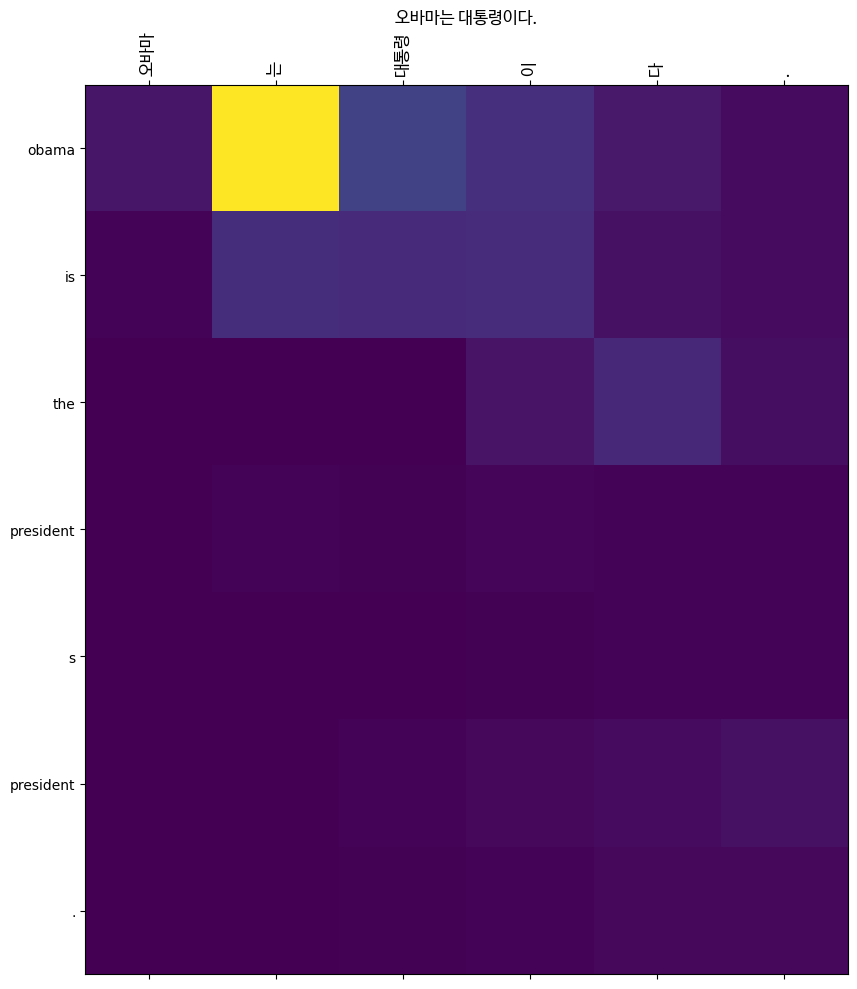

Input    : 시민들은 도시 속에 산다.
Tokenized: 시민 들 은 도시 속 에 산다 .
Output   : the number of the city of the city of the city of the city of the city of the city of the city of the city of the city of the city of the city of the city of the <end>


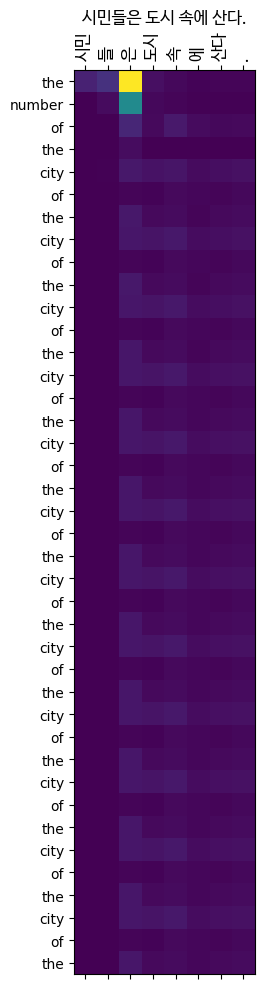

Input    : 커피는 필요 없다.
Tokenized: 커피 는 필요 없 다 .
Output   : if you can t be no longer . <end>


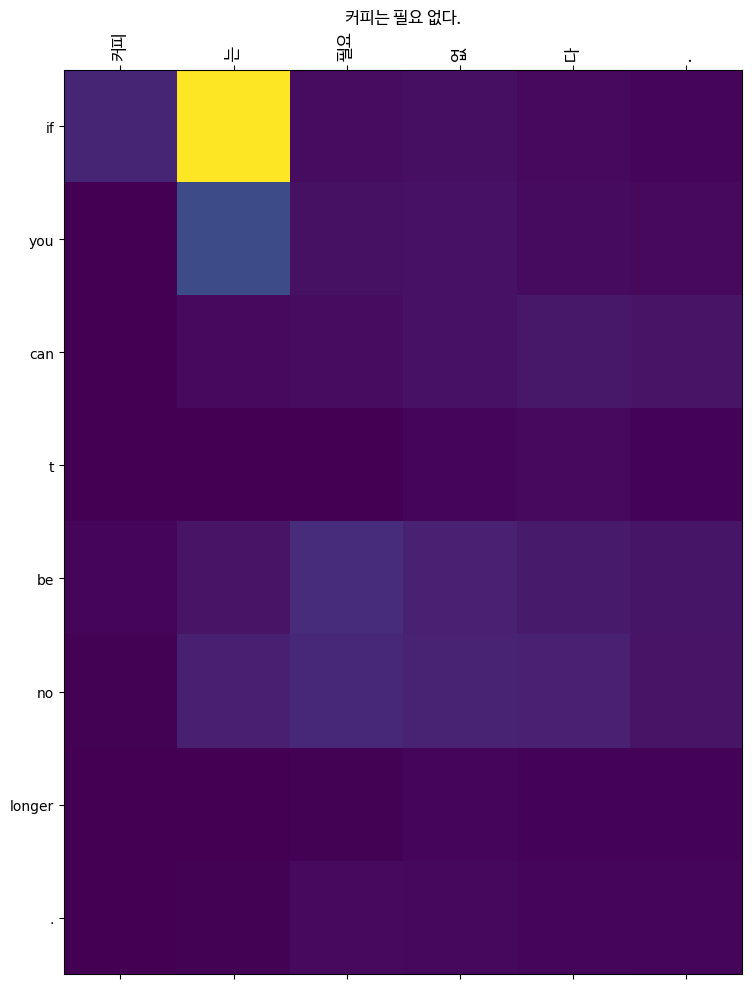

Input    : 일곱 명의 사망자가 발생했다.
Tokenized: 일곱 명 의 사망자 가 발생 했 다 .
Output   : seven people were killed . <end>


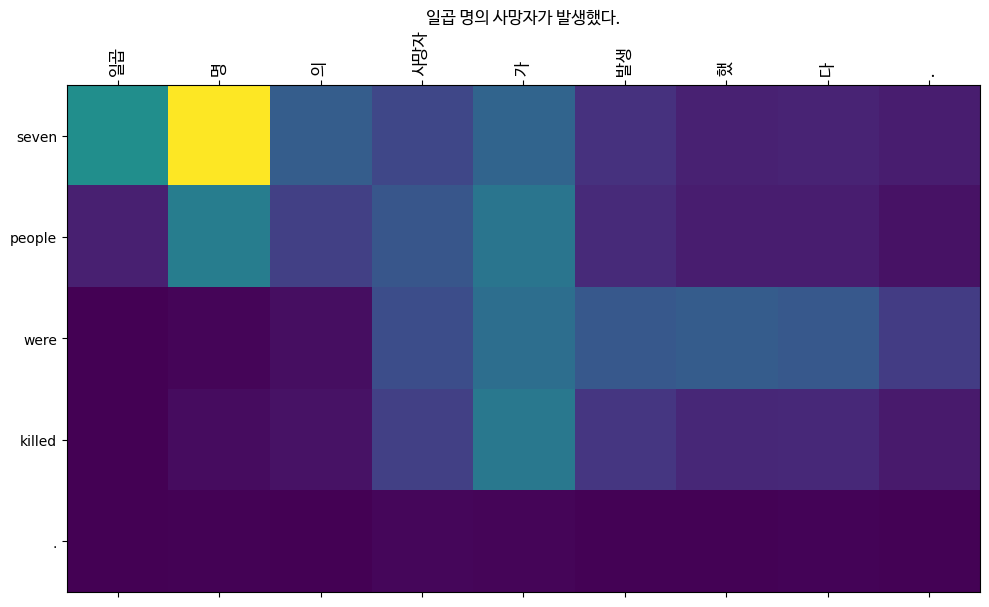

In [28]:
# Attention Map 시각화
for sentence in submit_sentences:
    translate(sentence)
